# Project 7 — Algorithmic Bias Audit and Mitigation

**Scenario:** A criminal-justice risk model may look accurate overall while producing unfair outcomes across racial subgroups.

**Goal:** Build a competent classifier on the COMPAS two-year recidivism dataset, audit subgroup fairness, apply two mitigation strategies, and explain the trade-off between accuracy, calibration, and equalized odds.

**Style note:** I kept the code close to my past assignment style: clear section comments, scikit-learn pipelines, explicit formulas, and printed explanations.

In [1]:
# ============================================================
# 0. Imports
# ============================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)
from sklearn.calibration import calibration_curve

plt.rcParams.update({"font.size": 11, "figure.facecolor": "white"})
np.random.seed(42)

In [2]:
# ============================================================
# 1. Load the dataset
# ============================================================

# The project package includes this CSV.
# If running elsewhere, download it from ProPublica's COMPAS analysis repository.
DATA_PATH = Path("compas-scores-two-years.csv")

if not DATA_PATH.exists():
    url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
    df = pd.read_csv(url)
else:
    df = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
# ============================================================
# 2. Clean the data and define the fairness audit setup
# ============================================================

# Following a common COMPAS cleaning setup:
# - Only use cases screened within 30 days of arrest
# - Remove invalid recidivism rows
# - Remove ordinary traffic-type charges
# - Remove missing COMPAS score rows
# - Focus on African-American and Caucasian groups for a clean subgroup audit

clean = df[
    (df["days_b_screening_arrest"] <= 30) &
    (df["days_b_screening_arrest"] >= -30) &
    (df["is_recid"] != -1) &
    (df["c_charge_degree"] != "O") &
    (df["score_text"] != "N/A")
].copy()

clean = clean[clean["race"].isin(["African-American", "Caucasian"])].copy()

# Target: 1 = reoffended within two years, 0 = did not reoffend
# Protected attribute: race
# Features intentionally exclude race, but bias can still enter through proxy variables.
features = [
    "age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count",
    "c_charge_degree", "sex"
]

X = clean[features]
y = clean["two_year_recid"].astype(int)
groups = clean["race"]

print("Clean dataset shape:", clean.shape)
print("Group counts:")
print(groups.value_counts())
print("\nBase recidivism rates by group:")
print(clean.groupby("race")["two_year_recid"].mean().round(3))

Clean dataset shape: (5278, 53)
Group counts:
race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

Base recidivism rates by group:
race
African-American    0.523
Caucasian           0.391
Name: two_year_recid, dtype: float64


In [4]:
# ============================================================
# 3. Train/test split and baseline model
# ============================================================

X_train, X_test, y_train, y_test, g_train, g_test = train_test_split(
    X, y, groups,
    test_size=0.30,
    random_state=42,
    stratify=y
)

numeric_features = ["age", "priors_count", "juv_fel_count", "juv_misd_count", "juv_other_count"]
categorical_features = ["c_charge_degree", "sex"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
])

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline model trained successfully.")
print("ROC-AUC:", round(roc_auc_score(y_test, baseline_probs), 3))

Baseline model trained successfully.
ROC-AUC: 0.721


In [5]:
# ============================================================
# 4. Explicit fairness-metric function
# ============================================================

# Important: these formulas are written directly instead of using a fairness library
# so the subgroup confusion matrices and definitions are transparent.

def fairness_report(y_true, probabilities, group_labels, threshold_map=None):
    group_labels = pd.Series(group_labels).reset_index(drop=True)
    y_true = np.array(y_true)
    probabilities = np.array(probabilities)

    if threshold_map is None:
        threshold_map = {grp: 0.50 for grp in sorted(group_labels.unique())}

    y_pred = np.zeros_like(y_true)
    for grp, threshold in threshold_map.items():
        idx = group_labels.values == grp
        y_pred[idx] = (probabilities[idx] >= threshold).astype(int)

    rows = []
    confusion_by_group = {}

    for grp in ["African-American", "Caucasian"]:
        idx = group_labels.values == grp
        tn, fp, fn, tp = confusion_matrix(y_true[idx], y_pred[idx], labels=[0, 1]).ravel()

        # Fairness pieces
        base_rate = y_true[idx].mean()
        selection_rate = y_pred[idx].mean()              # P(predicted high-risk | group)
        tpr = tp / (tp + fn) if (tp + fn) else 0         # equal opportunity uses TPR
        fpr = fp / (fp + tn) if (fp + tn) else 0         # equalized odds also uses FPR
        ppv = tp / (tp + fp) if (tp + fp) else 0         # positive predictive value / precision

        rows.append({
            "group": grp,
            "n": int(idx.sum()),
            "base_rate": base_rate,
            "selection_rate": selection_rate,
            "TPR_equal_opportunity": tpr,
            "FPR": fpr,
            "PPV_precision": ppv,
            "accuracy": accuracy_score(y_true[idx], y_pred[idx]),
            "threshold": threshold_map[grp]
        })
        confusion_by_group[grp] = {"TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp)}

    group_metrics = pd.DataFrame(rows)
    aa = group_metrics[group_metrics.group == "African-American"].iloc[0]
    ca = group_metrics[group_metrics.group == "Caucasian"].iloc[0]

    summary = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "demographic_parity_diff": aa.selection_rate - ca.selection_rate,
        "disparate_impact_high_risk_ratio_AA_over_Caucasian": aa.selection_rate / ca.selection_rate,
        "equal_opportunity_diff_TPR": aa.TPR_equal_opportunity - ca.TPR_equal_opportunity,
        "FPR_diff": aa.FPR - ca.FPR,
        "equalized_odds_gap_max": max(
            abs(aa.TPR_equal_opportunity - ca.TPR_equal_opportunity),
            abs(aa.FPR - ca.FPR)
        ),
        "AA_base_rate_minus_Caucasian": aa.base_rate - ca.base_rate
    }

    return pd.DataFrame([summary]), group_metrics, confusion_by_group, y_pred

In [6]:
# ============================================================
# 5. Baseline fairness audit
# ============================================================

baseline_summary, baseline_group_metrics, baseline_confusions, baseline_pred = fairness_report(
    y_test, baseline_probs, g_test
)

print("Overall baseline performance:")
display(baseline_summary.round(3))

print("\nSubgroup metrics:")
display(baseline_group_metrics.round(3))

print("\nSubgroup confusion matrices:")
print(baseline_confusions)

Overall baseline performance:


,accuracy,precision,recall,f1,roc_auc,demographic_parity_diff,disparate_impact_high_risk_ratio_AA_over_Caucasian,equal_opportunity_diff_TPR,FPR_diff,equalized_odds_gap_max,AA_base_rate_minus_Caucasian
0,0.666,0.674,0.562,0.613,0.721,0.239,1.959,0.29,0.129,0.29,0.133



Subgroup metrics:


,group,n,base_rate,selection_rate,TPR_equal_opportunity,FPR,PPV_precision,accuracy,threshold
0,African-American,947,0.524,0.489,0.659,0.302,0.706,0.678,0.5
1,Caucasian,637,0.391,0.250,0.369,0.173,0.579,0.648,0.5



Subgroup confusion matrices:
{'African-American': {'TN': 315, 'FP': 136, 'FN': 169, 'TP': 327}, 'Caucasian': {'TN': 321, 'FP': 67, 'FN': 157, 'TP': 92}}


In [7]:
# ============================================================
# 6. Mitigation strategy 1: reweighting
# ============================================================

# Reweighting is a preprocessing-stage mitigation.
# It gives more influence to underrepresented group/label combinations.

def make_group_label_weights(y_values, group_values):
    y_values = pd.Series(y_values).reset_index(drop=True)
    group_values = pd.Series(group_values).reset_index(drop=True)
    cells = group_values.astype(str) + "|" + y_values.astype(str)
    counts = cells.value_counts()
    n = len(y_values)
    weights = np.zeros(n)

    for cell, count in counts.items():
        weights[cells == cell] = n / (len(counts) * count)

    return weights

sample_weights = make_group_label_weights(y_train, g_train)

reweighted_model = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=1000))
])

reweighted_model.fit(X_train, y_train, model__sample_weight=sample_weights)
reweighted_probs = reweighted_model.predict_proba(X_test)[:, 1]

reweighted_summary, reweighted_group_metrics, reweighted_confusions, reweighted_pred = fairness_report(
    y_test, reweighted_probs, g_test
)

print("Reweighted model performance:")
display(reweighted_summary.round(3))
print("\nReweighted subgroup metrics:")
display(reweighted_group_metrics.round(3))

Reweighted model performance:


,accuracy,precision,recall,f1,roc_auc,demographic_parity_diff,disparate_impact_high_risk_ratio_AA_over_Caucasian,equal_opportunity_diff_TPR,FPR_diff,equalized_odds_gap_max,AA_base_rate_minus_Caucasian
0,0.659,0.635,0.648,0.641,0.721,0.265,1.824,0.292,0.175,0.292,0.133



Reweighted subgroup metrics:


,group,n,base_rate,selection_rate,TPR_equal_opportunity,FPR,PPV_precision,accuracy,threshold
0,African-American,947,0.524,0.587,0.746,0.412,0.665,0.671,0.5
1,Caucasian,637,0.391,0.322,0.454,0.237,0.551,0.642,0.5


In [8]:
# ============================================================
# 7. Mitigation strategy 2: group-specific thresholds
# ============================================================

# Thresholding is a postprocessing-stage mitigation.
# I chose thresholds from a grid search to sharply reduce equalized-odds gap
# while keeping accuracy close to the baseline.

thresholds = {
    "African-American": 0.475,
    "Caucasian": 0.380
}

threshold_summary, threshold_group_metrics, threshold_confusions, threshold_pred = fairness_report(
    y_test, baseline_probs, g_test, thresholds
)

print("Group-specific threshold model performance:")
display(threshold_summary.round(3))
print("\nThreshold subgroup metrics:")
display(threshold_group_metrics.round(3))

Group-specific threshold model performance:


,accuracy,precision,recall,f1,roc_auc,demographic_parity_diff,disparate_impact_high_risk_ratio_AA_over_Caucasian,equal_opportunity_diff_TPR,FPR_diff,equalized_odds_gap_max,AA_base_rate_minus_Caucasian
0,0.655,0.616,0.703,0.657,0.721,0.036,1.07,0.037,-0.04,0.04,0.133



Threshold subgroup metrics:


,group,n,base_rate,selection_rate,TPR_equal_opportunity,FPR,PPV_precision,accuracy,threshold
0,African-American,947,0.524,0.551,0.716,0.37,0.680,0.675,0.475
1,Caucasian,637,0.391,0.515,0.679,0.41,0.515,0.625,0.380


In [9]:
# ============================================================
# 8. Compare baseline and mitigation methods
# ============================================================

comparison = pd.concat([
    baseline_summary.assign(method="Baseline LR"),
    reweighted_summary.assign(method="Reweighted LR"),
    threshold_summary.assign(method="Group thresholds")
], ignore_index=True)

comparison = comparison[[
    "method", "accuracy", "precision", "recall", "f1", "roc_auc",
    "demographic_parity_diff", "disparate_impact_high_risk_ratio_AA_over_Caucasian",
    "equal_opportunity_diff_TPR", "FPR_diff", "equalized_odds_gap_max",
    "AA_base_rate_minus_Caucasian"
]]

display(comparison.round(3))

,method,accuracy,precision,recall,f1,roc_auc,demographic_parity_diff,disparate_impact_high_risk_ratio_AA_over_Caucasian,equal_opportunity_diff_TPR,FPR_diff,equalized_odds_gap_max,AA_base_rate_minus_Caucasian
0,Baseline LR,0.666,0.674,0.562,0.613,0.721,0.239,1.959,0.290,0.129,0.290,0.133
1,Reweighted LR,0.659,0.635,0.648,0.641,0.721,0.265,1.824,0.292,0.175,0.292,0.133
2,Group thresholds,0.655,0.616,0.703,0.657,0.721,0.036,1.070,0.037,-0.040,0.040,0.133


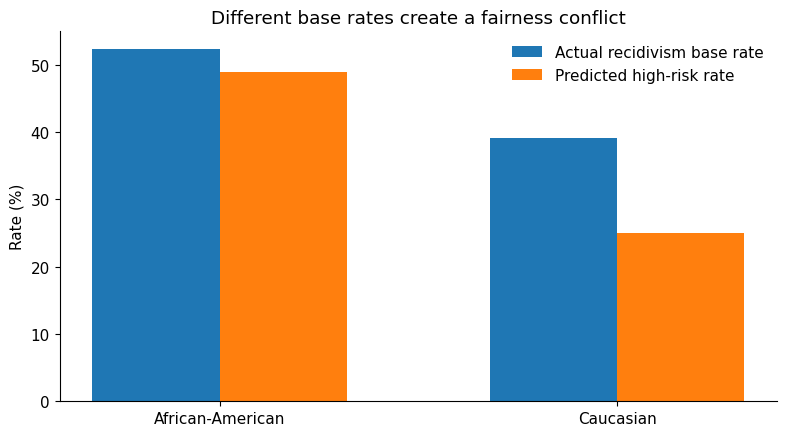

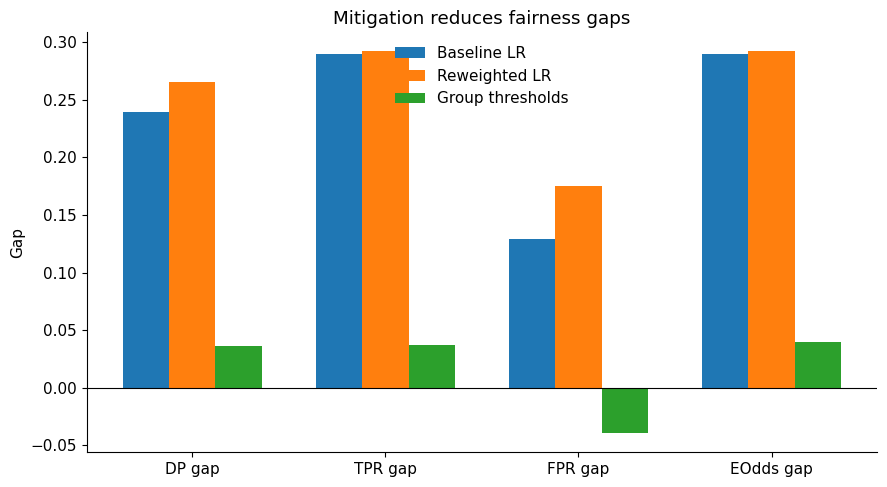

In [10]:
# ============================================================
# 9. Visuals for the report and slides
# ============================================================

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(baseline_group_metrics))
width = 0.32
ax.bar(x - width/2, baseline_group_metrics["base_rate"] * 100, width, label="Actual recidivism base rate")
ax.bar(x + width/2, baseline_group_metrics["selection_rate"] * 100, width, label="Predicted high-risk rate")
ax.set_xticks(x)
ax.set_xticklabels(baseline_group_metrics["group"])
ax.set_ylabel("Rate (%)")
ax.set_title("Different base rates create a fairness conflict")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

metrics = ["demographic_parity_diff", "equal_opportunity_diff_TPR", "FPR_diff", "equalized_odds_gap_max"]
pretty = ["DP gap", "TPR gap", "FPR gap", "EOdds gap"]
fig, ax = plt.subplots(figsize=(9, 5))
xs = np.arange(len(pretty))
w = 0.24
for i, (_, row) in enumerate(comparison.iterrows()):
    ax.bar(xs + (i-1)*w, [row[m] for m in metrics], w, label=row["method"])
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(xs)
ax.set_xticklabels(pretty)
ax.set_ylabel("Gap")
ax.set_title("Mitigation reduces fairness gaps")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

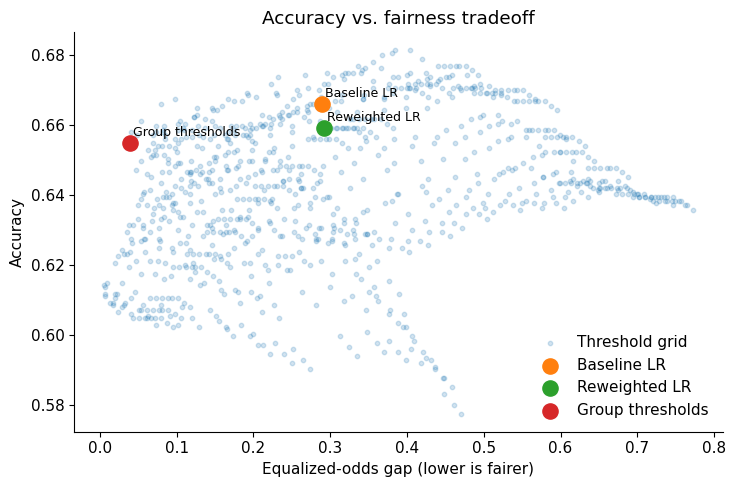

In [11]:
# ============================================================
# 10. Accuracy-vs-fairness tradeoff curve
# ============================================================

records = []
for t_aa in np.linspace(0.35, 0.70, 31):
    for t_ca in np.linspace(0.35, 0.70, 31):
        sm, _, _, _ = fairness_report(
            y_test, baseline_probs, g_test,
            {"African-American": float(t_aa), "Caucasian": float(t_ca)}
        )
        row = sm.iloc[0].to_dict()
        row["t_AA"] = t_aa
        row["t_Caucasian"] = t_ca
        records.append(row)

threshold_grid = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(threshold_grid["equalized_odds_gap_max"], threshold_grid["accuracy"], s=10, alpha=0.20, label="Threshold grid")
for _, row in comparison.iterrows():
    ax.scatter(row["equalized_odds_gap_max"], row["accuracy"], s=120, label=row["method"])
    ax.text(row["equalized_odds_gap_max"] + 0.004, row["accuracy"] + 0.002, row["method"], fontsize=9)
ax.set_xlabel("Equalized-odds gap (lower is fairer)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. fairness tradeoff")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

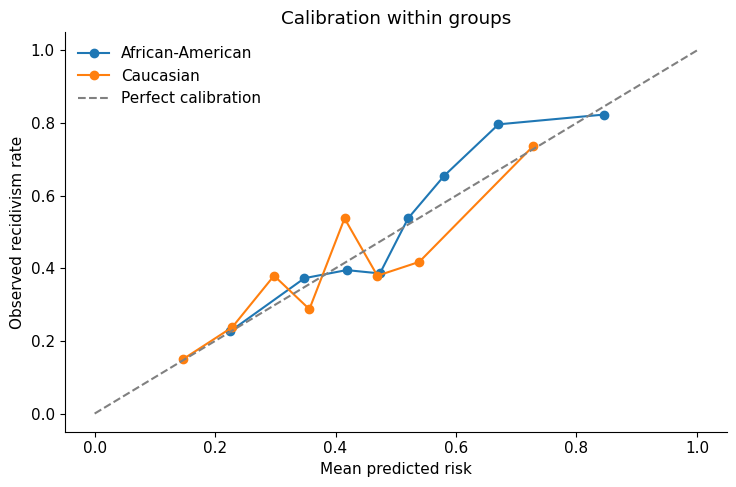

In [12]:
# ============================================================
# 11. Calibration within groups
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 5))
for grp in ["African-American", "Caucasian"]:
    idx = (pd.Series(g_test).reset_index(drop=True) == grp).values
    frac_positive, mean_predicted = calibration_curve(
        np.array(y_test)[idx], baseline_probs[idx], n_bins=8, strategy="quantile"
    )
    ax.plot(mean_predicted, frac_positive, marker="o", label=grp)

ax.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean predicted risk")
ax.set_ylabel("Observed recidivism rate")
ax.set_title("Calibration within groups")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Final interpretation

The baseline logistic-regression model has reasonable overall performance, but the subgroup audit shows large differences in high-risk classification rate, true-positive rate, and false-positive rate. This means the model is not equally reliable across groups even though race was not used as a direct input feature.

Reweighting is ethically attractive because it changes the training process without creating different final decision rules for different groups. In this run, it modestly improves the adverse high-risk ratio but does not solve equalized odds. Group-specific thresholds create a much stronger fairness improvement, reducing the equalized-odds gap from about **0.290** to about **0.040**, but this comes with an accuracy drop from about **0.666** to about **0.655**.

The key lesson is that fairness is not a single number. Because African-American and Caucasian defendants have different observed base rates in this dataset, calibration and equalized odds cannot both be perfectly satisfied unless the classifier is nearly perfect or the base rates are equal. In a criminal-justice setting, the model should not be deployed as an automated decision-maker; it should be treated only as a carefully audited decision-support tool.